##

# Lag and KS test + for loop

# Test violation for regressions

# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Realtime analysis

In [2]:
df = pd.read_csv("../datasets/farm_cat.csv")
# df = df[df["territory"] == "All Australia"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

# df = df[~df["territory"].str.contains("All Australia", case=False, na=False)]


Null count

In [3]:
print(df.isnull().sum())

year                      0
territory                 0
lambs                    14
rams                     14
ewes                     14
lamb_sheep_shorn          0
sheep_flock               0
sheep_purchased           0
cats_occurrence_total    42
cats_forest              42
dtype: int64


# Visualizing patterns count plot, historgram with kde distr, and scatter plot

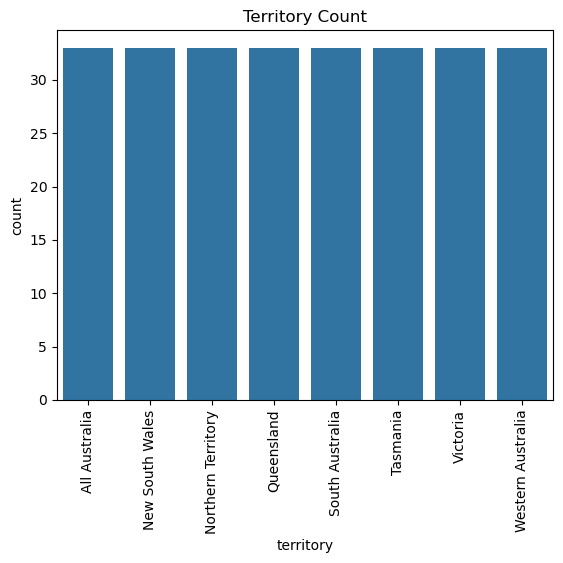

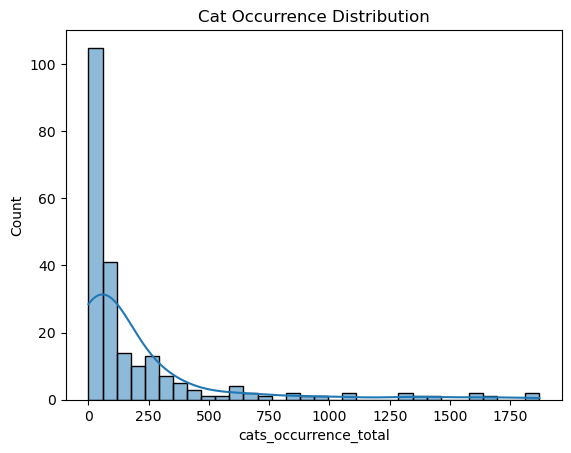

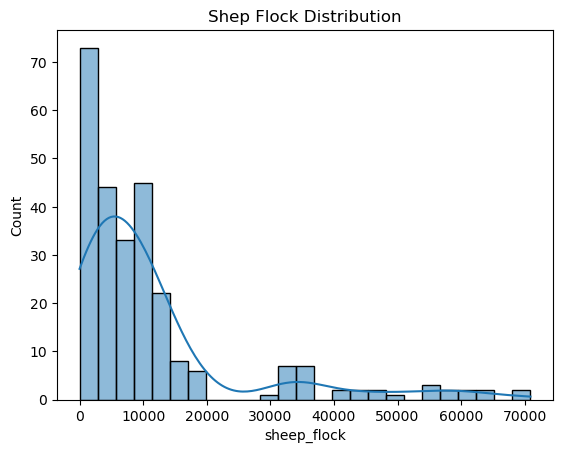

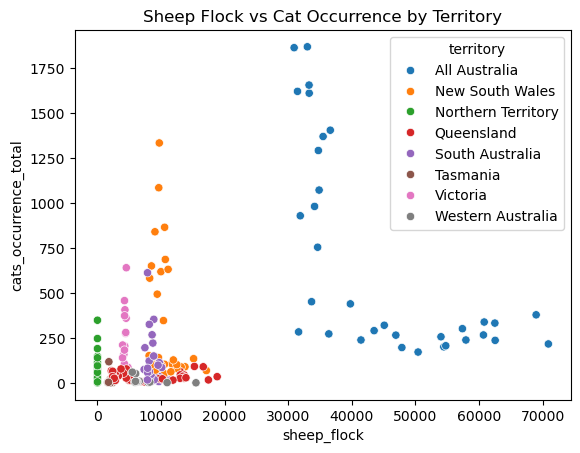

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='territory', data=df)
plt.title("Territory Count")
plt.xticks(rotation=90)
plt.show()

sns.histplot(df['cats_occurrence_total'], kde=True)
plt.title("Cat Occurrence Distribution") # Log scaled
plt.show()

sns.histplot(df['sheep_flock'], kde=True)
plt.title("Shep Flock Distribution") # Log scaled
plt.show()

sns.scatterplot(x='sheep_flock', y='cats_occurrence_total', hue='territory', data=df)
plt.title("Sheep Flock vs Cat Occurrence by Territory")
plt.show()

#### We see that both cats and sheep flock are log scaled distributions so we'll use log scale

In [12]:
df["log_sheep"] = np.log1p(df["sheep_purchased"])
df["log_cats"] = np.log1p(df["cats_occurrence_total"])

Text(0.5, 1.0, 'Log Cat and Sheep Scatter by territory (incl AllAus)')

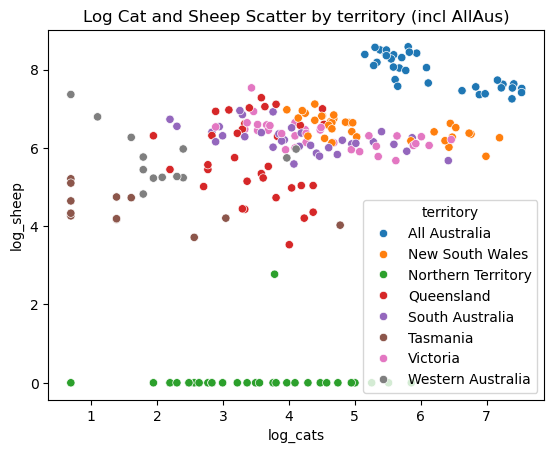

In [ ]:
sns.scatterplot(x=df['log_cats'], y=df['log_sheep'], hue='territory', data=df)
plt.title('Log-scaled Cat and Sheep Scatter')

## Linear Regression Model: Two sets - All territories and by territory

In [5]:
df_reg = df[["sheep_flock", "cats_occurrence_total"]].copy()

imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed.head()

,sheep_flock,cats_occurrence_total
0,70896.0,217.0
1,17123.0,69.0
2,4.0,43.0
3,17443.0,17.0
4,10952.0,26.0


In [6]:
X = df_reg_imputed[["cats_occurrence_total"]]
y = df_reg_imputed["sheep_flock"]


In [7]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

  Coefficient: 18.0429
  R²         : 0.1629
  RMSE       : 12,993.59


### Linear Regression with more variables

This ones for all territories, we only imputed numerical columns

In [14]:
df_reg = df[["sheep_purchased", "cats_occurrence_total", "year", "territory"]].copy()

# Numeric and categorical separation
numeric_cols = ["sheep_purchased", "cats_occurrence_total", "year"]
categorical_cols = ["territory"]

# Imputing numeric only
imputer = SimpleImputer(strategy="mean")
df_numeric_imputed = pd.DataFrame(
    imputer.fit_transform(df_reg[numeric_cols]),
    columns=numeric_cols
)

# Add territory back
df_numeric_imputed["territory"] = df_reg["territory"].values

# Encode territory
df_encoded = pd.get_dummies(
    df_numeric_imputed,
    columns=["territory"],
    drop_first=True
)

X = df_encoded.drop(columns=["sheep_purchased"])
y = df_encoded["sheep_purchased"]

In [15]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

  Coefficient: -0.8122
  R²         : 0.8666
  RMSE       : 380.90


This one is for modelling for separate territories

In [ ]:
for territory in df["territory"].unique():
    # Filter territory
    df_t = df[df["territory"] == territory]

    df_reg = df_t[["sheep_purchased", "cats_occurrence_total", "year"]].copy()

    # Impute
    imputer = SimpleImputer(strategy="mean")
    df_reg_imputed = pd.DataFrame(
        imputer.fit_transform(df_reg),
        columns=df_reg.columns
    )

    X = df_reg_imputed.drop(columns=["sheep_purchased"])
    y = df_reg_imputed["sheep_purchased"]

    model = LinearRegression()
    model.fit(X, y)

    r2 = model.score(X, y)

    print(f"Territory: {territory}")
    print("Intercept:", model.intercept_)
    print(f"  Coefficient: {model.coef_[0]:,.4f}")
    print(f"  R²         : {r2:.4f}")
    print(f"  RMSE       : {rmse:,.2f}")

All Australia
R²: 0.808
Intercept: 234587.0960127459
  Coefficient: -0.0585
  R²         : 0.8076
  RMSE       : 1,163.08
New South Wales
R²: 0.418
Intercept: 19226.934444490973
  Coefficient: -0.1674
  R²         : 0.4176
  RMSE       : 1,163.08
Northern Territory
R²: 0.091
Intercept: 169.66544375303326
  Coefficient: 0.0017
  R²         : 0.0907
  RMSE       : 1,163.08
Queensland
R²: 0.716
Intercept: 73474.4084844136
  Coefficient: -0.5803
  R²         : 0.7160
  RMSE       : 1,163.08
South Australia
R²: 0.570
Intercept: 31210.432802573658
  Coefficient: 0.0234
  R²         : 0.5703
  RMSE       : 1,163.08
Tasmania
R²: 0.194
Intercept: 5148.59543777287
  Coefficient: -0.2405
  R²         : 0.1936
  RMSE       : 1,163.08
Victoria
R²: 0.254
Intercept: 30144.903865262786
  Coefficient: 0.0291
  R²         : 0.2540
  RMSE       : 1,163.08
Western Australia
R²: 0.676
Intercept: 75115.84716819739
  Coefficient: 3.3115
  R²         : 0.6758
  RMSE       : 1,163.08


### $R^2$ ranking of the above:

\[
\begin{array}{l|c}
\text{Territory} & R^2 \\
\hline
\text{All Australia}      & 0.8076 \\
\text{Queensland}         & 0.7160 \\
\text{Western Australia}  & 0.6758 \\
\text{South Australia}    & 0.5703 \\
\text{New South Wales}    & 0.4176 \\
\text{Victoria}           & 0.2540 \\
\text{Tasmania}           & 0.1936 \\
\text{Northern Territory} & 0.0907 \\
\end{array}
\]

### Regressions by state


In [13]:
results_territory = {}

In [14]:
df = pd.read_csv("../datasets/farm_cat.csv")
df = df[df["territory"] == "New South Wales"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


In [15]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["New South Wales"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 439225.04452959396
                 Feature  Coefficient
0  cats_occurrence_total     2.216945
1                   year  -213.933342
  Coefficient: 2.2169
  R²         : 0.6314
  RMSE       : 1,220.71


In [16]:
df = pd.read_csv("../datasets/farm_cat.csv")
df = df[df["territory"] == "Western Australia"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


In [17]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["Western Australia"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 873428.7527866664
                 Feature  Coefficient
0  cats_occurrence_total    26.041135
1                   year  -430.361646
  Coefficient: 26.0411
  R²         : 0.8938
  RMSE       : 1,392.71


In [18]:
df = pd.read_csv("../datasets/farm_cat.csv")
df = df[df["territory"] == "Tasmania"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


In [19]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["Tasmania"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 50633.74994815513
                 Feature  Coefficient
0  cats_occurrence_total     0.533081
1                   year   -24.201185
  Coefficient: 0.5331
  R²         : 0.5070
  RMSE       : 225.77


In [20]:
df = pd.read_csv("../datasets/farm_cat.csv")
print(df["territory"].unique())
df = df[df["territory"] == "Northern Territory"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


['All Australia' 'New South Wales' 'Northern Territory' 'Queensland'
 'South Australia' 'Tasmania' 'Victoria' 'Western Australia']


In [21]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["Northern Territory"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 157.59159427484556
                 Feature  Coefficient
0  cats_occurrence_total    -0.004884
1                   year    -0.077792
  Coefficient: -0.0049
  R²         : 0.0470
  RMSE       : 4.16


In [22]:
df = pd.read_csv("../datasets/farm_cat.csv")
df = df[df["territory"] == "Queensland"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


In [23]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["Queensland"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 1058298.495570299
                 Feature  Coefficient
0  cats_occurrence_total     5.613735
1                   year  -523.542194
  Coefficient: 5.6137
  R²         : 0.9067
  RMSE       : 1,600.13


In [24]:
df = pd.read_csv("../datasets/farm_cat.csv")
df = df[df["territory"] == "South Australia"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


In [25]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["South Australia"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 125688.19057159756
                 Feature  Coefficient
0  cats_occurrence_total    -0.043858
1                   year   -58.217545
  Coefficient: -0.0439
  R²         : 0.3331
  RMSE       : 788.71


In [26]:
df = pd.read_csv("../datasets/farm_cat.csv")
df = df[df["territory"] == "All Australia"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


In [27]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["All Australia"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 2962729.2572252103
                 Feature  Coefficient
0  cats_occurrence_total     5.037126
1                   year -1456.189828
  Coefficient: 5.0371
  R²         : 0.9077
  RMSE       : 3,730.41


In [28]:
results_territory

{'New South Wales': {'intercept': 439225.04452959396,
  'coefficients': {'cats_occurrence_total': 2.2169454438626066,
   'year': -213.93334158822415},
  'r2': 0.6313565980816733,
  'rmse': 1220.7089936787947},
 'Western Australia': {'intercept': 873428.7527866664,
  'coefficients': {'cats_occurrence_total': 26.04113484453956,
   'year': -430.3616456651688},
  'r2': 0.8937763857814218,
  'rmse': 1392.7134201591296},
 'Tasmania': {'intercept': 50633.74994815513,
  'coefficients': {'cats_occurrence_total': 0.5330810455458311,
   'year': -24.201184805162715},
  'r2': 0.5069966167690996,
  'rmse': 225.76702121635006},
 'Northern Territory': {'intercept': 157.59159427484556,
  'coefficients': {'cats_occurrence_total': -0.0048836001050010965,
   'year': -0.07779164981355434},
  'r2': 0.04698578330791514,
  'rmse': 4.16284535723601},
 'Queensland': {'intercept': 1058298.495570299,
  'coefficients': {'cats_occurrence_total': 5.61373465265882,
   'year': -523.5421940488318},
  'r2': 0.9066850513

# Stat Analysis

In [29]:
# # Statistical analysis - Liza
# merged = df.groupby(['year', 'ibraRegion'])['occurrenceCount'].sum().reset_index()


# for state in merged['ibraRegion'].unique():
#     state_df = merged[merged['ibraRegion'] == state]

#     X = sm.add_constant(state_df['year'])
#     y = state_df['occurrenceCount']

#     model = sm.OLS(y, X).fit()
#     print(f"\n{state}")
#     print(model.summary())